In [1]:
from pathlib import Path

"""
Replace with your desired directories
"""

from utility import repo_root

FIG_DIR = Path("/Users/zach/2025_RA/matthias/final images/4_expanded_sleep")
BIDS_DIR = Path("/Users/zach/2025_RA/matthias/bids_sleepmreye")
CONFIG_DIR = Path(repo_root() / "sleepmreye" / "designs")

In [3]:
""" Load data """

from mreyemove.analysis.glm.cli import construct_desc
from mreyemove.analysis.glm.config import GLMConfig
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root=BIDS_DIR,
    data_dir=BIDS_DIR / "derivatives"/ "fmriprep",
    tr=2.1,
    task="sleep",
    load_signal=True,
    desc_add="clean",
    ignore_boundary_trs=0,
    load_eog=False,
)

config = GLMConfig.from_yaml(CONFIG_DIR / "original.yml")
desc_add = construct_desc(dataset=mrio, config=config)
desc_add = f"{desc_add}-{config.second_level.method}"
print(desc_add)

clean-original-flame


# Figure A - Searchlight Correlation

In [4]:

comparisons = [
    ("mreyemove_W", "mreyemove_1"),
    ("mreyemove_W", "mreyemove_2"),
]
corr_maps = {}


In [5]:
"""
Building neighbourhoods takes a while - just do it once
"""

from mreyemove.analysis.searchlight_correlation import build_fsaverage_neighborhoods
radius_mm = 23  # geodesic radius in mm
surf_mesh = "fsaverage7"

neighborhoods = build_fsaverage_neighborhoods(surf_mesh=surf_mesh, radius_mm=radius_mm)

[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
Building geodesic neighborhoods (radius=23mm)...


Dijkstra neighborhoods:   0%|          | 0/328 [00:00<?, ?it/s]

Neighbors — Mean: 830, Median: 787, Min: 254, Max: 2009
Building geodesic neighborhoods (radius=23mm)...


Dijkstra neighborhoods:   0%|          | 0/328 [00:00<?, ?it/s]

Neighbors — Mean: 846, Median: 799, Min: 285, Max: 2059


In [6]:
"""
Wake vs Sleep Cerebrum Searchlight
"""

from SleepMReye.plotting import plot_surface_searchlight
from mreyemove.analysis.searchlight_correlation import run_fsaverage_surface_searchlight_correlation

for contrast_a, contrast_b in comparisons:
    print(f"\n=== {contrast_a} vs {contrast_b} ===")

    data_a, _ = mrio.load_FLAME_result(contrast=contrast_a, desc_add=desc_add)
    data_b, _ = mrio.load_FLAME_result(contrast=contrast_b, desc_add=desc_add)

    print(data_a.t_stat.shape)

    corr_map, _ = run_fsaverage_surface_searchlight_correlation(
        data_b.t_stat, data_a.t_stat,
        surf_mesh=surf_mesh,
        neighborhoods=neighborhoods
    )
    corr_maps[f"{contrast_a}_{contrast_b}"] = corr_map

    plot_surface_searchlight(
        corr_map,
        surf_mesh=surf_mesh,
        inflate=True,
        title=f"Searchlight r: {contrast_a} vs {contrast_b} ({radius_mm}mm geodesic)",
        output_file=FIG_DIR / f"{contrast_a}_{contrast_b}_{radius_mm}mm_correlation_map.png"
    )


=== mreyemove_W vs mreyemove_1 ===
(53, 65, 43)
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
Running left hemisphere
n vertices = 163842
r_valid >=  0.3: 63.5%
r_valid <= -0.3: 6.3%
n valid vertices = 163308
r_valid >=  0.3: 63.7%
r_valid <= -0.3: 6.4%
Median r: 0.4535737633705139
Running right hemisphere
n vertices = 163842
r_valid >=  0.3: 60.1%
r_valid <= -0.3: 9.2%
n valid vertices = 163775
r_valid >=  0.3: 60.1%
r_valid <= -0.3: 9.2%
Median r: 0.43500715494155884
Joint hemisphere median r: 0.44495752453804016
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage

=== mreyemove_W vs mreyemove_2 ===
(53, 65, 43)
[fetch_surf_fsaverage] Dataset found in /Users/zach/nilearn_data/fsaverage
Running left hemisphere
n vertices = 163842
r_valid >=  0.3: 50.1%
r_valid <= -0.3: 13.7%
n valid vertices = 163307
r_valid >=  0.3: 50.3%
r_valid <= -0.3: 13.7%
Median r: 0.3033483624458313
Running right hemisphere
n vertices = 163842
r_valid >=  0.

In [7]:
"""
Building neighbourhoods takes a while - just do it once
"""
import os
from SUITPy import flatmap
from mreyemove.analysis.searchlight_correlation import build_neighbourhoods


radius_mm = 11.0
surf_path = os.path.join(flatmap._base_dir,'surfaces', f'PIAL_FSL.surf.gii')
neighbourhoods = build_neighbourhoods(surf_mesh=surf_path, radius_mm=radius_mm)


Building geodesic neighborhoods (radius=11.0mm)...


Dijkstra neighborhoods:   0%|          | 0/58 [00:00<?, ?it/s]

Neighbors — Mean: 124, Median: 125, Min: 1, Max: 190



=== Cerebellum mreyemove_mreyemove_W vs mreyemove_mreyemove_1 ===
n vertices = 28935
r_valid >=  0.3: 62.3%
r_valid <= -0.3: 8.8%
n valid vertices = 28834
r_valid >=  0.3: 62.5%
r_valid <= -0.3: 8.9%
Median r: 0.4738333374261856

=== Cerebellum mreyemove_mreyemove_W vs mreyemove_mreyemove_2 ===
n vertices = 28935
r_valid >=  0.3: 56.8%
r_valid <= -0.3: 12.5%
n valid vertices = 28834
r_valid >=  0.3: 57.0%
r_valid <= -0.3: 12.6%
Median r: 0.3965880125761032


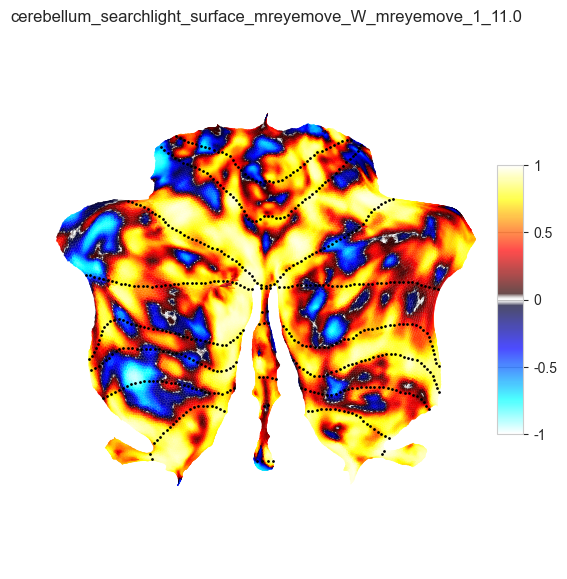

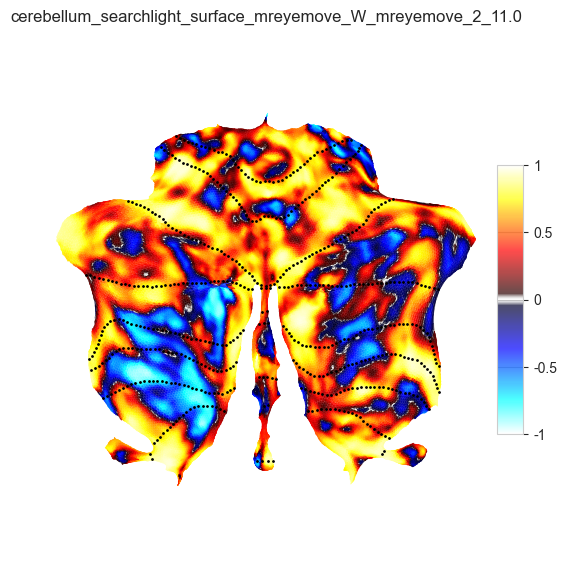

In [8]:
from mreyemove.plotting.glm import custom_cmap

"""
Wake vs Sleep Cerebellum Searchlight
"""

from SUITPy import flatmap
from mreyemove.analysis.searchlight_correlation import surface_searchlight_correlation

config = GLMConfig.from_yaml(CONFIG_DIR / "original_cer.yml")
desc_add = construct_desc(dataset=mrio, config=config)
desc_add = f"{desc_add}-{config.second_level.method}"
for contrast_a, contrast_b in comparisons:
    print(f"\n=== Cerebellum mreyemove_{contrast_a} vs mreyemove_{contrast_b} ===")
    title = f"cerebellum_searchlight_surface_{contrast_a}_{contrast_b}_{radius_mm}"
    
    vol_a,_ = mrio.load_FLAME_result(contrast=contrast_a, desc_add=desc_add)
    vol_b,_ = mrio.load_FLAME_result(contrast=contrast_b, desc_add=desc_add)
    
    surf_a = flatmap.vol_to_surf(vol_a.t_stat, space='FSL')
    surf_b = flatmap.vol_to_surf(vol_b.t_stat, space='FSL')
    
    results = surface_searchlight_correlation(
        map_a_surf=surf_a,
        map_b_surf=surf_b,
        neighborhoods=neighbourhoods,
        min_vertices=10,
    )
    
    corr_maps[f"cerebellum_{contrast_a}_{contrast_b}"] = results
    
    ax = flatmap.plot(data=results, cmap=custom_cmap(), 
            new_figure=True, 
            colorbar=True, 
            render='matplotlib',
            cscale=[-1.0, 1.0])
    ax.set_title(title)

    output_path = FIG_DIR / f"{title}.png"

    ax.figure.savefig(output_path, format="png", dpi=300, bbox_inches="tight")


# TR stats

In [9]:
import pandas as pd 
import numpy as np 

def compute_stat_df(
    df: pd.DataFrame,
    state_cols: list[str],
    subject_col: str = "subject",
    run_col: str = "run",
) -> pd.DataFrame:
    """

    Parameters
    ----------
    df : pd.DataFrame
        Long-format events dataframe with one row per TR, containing
        subject_col, run_col, and the state mask columns.
    state_cols : list[str]
        Names of boolean state mask columns.
    subject_col, run_col : str
        Column names for grouping.

    Returns
    -------
    pd.DataFrame
        One row per (subject, run, state) with columns:
        - n_trs_total: total TRs in the run
        - n_trs_original: TRs where original mask is True
        - n_trs_eroded: TRs where eroded mask is True
        - n_trs_lost: TRs lost to erosion
        - pct_lost_of_run: lost TRs as % of run length
        - pct_lost_of_state: lost TRs as % of original state coverage
        - n_transitions: number of state changes in the run
    """
    rows = []
    for (subj, run), group in df.groupby([subject_col, run_col], sort=False):
        n_total = len(group)
        for state in state_cols:
            mask = group[state].to_numpy()
            signal = group["mreyemove"][mask]
            n_orig = int(mask.sum())
            rows.append({
                subject_col: subj,
                run_col: run,
                "state": state,
                "n_trs_total": n_total,
                "n_trs": n_orig,
                "mean_signal": np.mean(signal),
                "std_signal": np.std(signal),
            })
    return pd.DataFrame(rows)

In [10]:
df = mrio.events
state = ["W", "S", "1", "2"]
stat_df = compute_stat_df(df, state_cols=state)

stat = "n_trs"
per_subject = (stat_df.groupby(["subject", "state"])[stat]
           .mean()  # mean across runs per subject
           .reset_index())

print(stat)
summary = per_subject.groupby("state")[stat].agg(
    median="median",
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75),
)
print(summary)

n_trs
           median         q25         q75
state                                    
1      128.000000   71.458333  194.075000
2       49.666667    6.583333  122.333333
S      230.000000  140.428571  290.416667
W      197.000000  104.333333  285.571429
